# Cadenas de Markov Ocultas (HMM) y Filtrado Bayesiano
**Estadística Bayesiana** | UAEMex Valle de México  
Ximena Quintanar Leal · 2025

> *"El filtro de Bayes y la etapa de selección en algoritmos genéticos comparten la misma estructura matemática."*  
> — César Galindo, §11.4

---


## 1. Modelo

Un **Hidden Markov Model (HMM)** tiene dos niveles:

1. **Estado oculto** $(X_n)_{n\geq 0}$ — cadena de Markov con kernel $K(x, x')$
2. **Observaciones** $(Y_n)_{n\geq 0}$ — condicionalmente independientes dado el estado oculto:

$$P(Y_n \in dy \mid X_n = x) = g(y \mid x)\,\nu(dy)$$

El objetivo del **filtrado** es calcular:

$$\phi_n(dx) = P(X_n \in dx \mid Y_0 = y_0, \ldots, Y_n = y_n)$$

### Recursión de filtrado de Bayes

$$\phi_n(dx) = \frac{g(y_n \mid x)\int_E K(x',dx)\,\phi_{n-1}(dx')}{\int_E g(y_n \mid z)\int_E K(x',dz)\,\phi_{n-1}(dx')}$$

**Clave:** esto es un **cambio de medida** — la predictiva se repondera por la verosimilitud $g(y_n \mid \cdot)$.


## 2. Implementación del algoritmo hacia adelante (forward algorithm)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(7)

# ─── Parámetros del HMM (dos regímenes: Bajo y Alto) ───
estados  = ['Bajo', 'Alto']
n_estados = 2

# Matriz de transición K (filas = estado actual, cols = estado siguiente)
K = np.array([[0.92, 0.08],   # desde Bajo: 92% queda en Bajo, 8% salta a Alto
              [0.15, 0.85]])   # desde Alto: 15% baja, 85% permanece en Alto

# Emisión gaussiana: Y | X=i ~ N(mu_i, sigma_i)
mu_emision    = np.array([-1.0, 2.0])   # media por estado
sig_emision   = np.array([ 1.0, 1.0])  # desv. estándar

def log_verosimilitud(y, mu, sig):
    return norm.logpdf(y, loc=mu, scale=sig)

def g(y, estado):
    return norm.pdf(y, loc=mu_emision[estado], scale=sig_emision[estado])

print("HMM configurado:")
print(f"  Estados: {estados}")
print(f"  Matriz K:\n{K}")
print(f"  Emisiones: Bajo ~ N({mu_emision[0]}, {sig_emision[0]}²),  Alto ~ N({mu_emision[1]}, {sig_emision[1]}²)")


HMM configurado:
  Estados: ['Bajo', 'Alto']
  Matriz K:
[[0.92 0.08]
 [0.15 0.85]]
  Emisiones: Bajo ~ N(-1.0, 1.0²),  Alto ~ N(2.0, 1.0²)


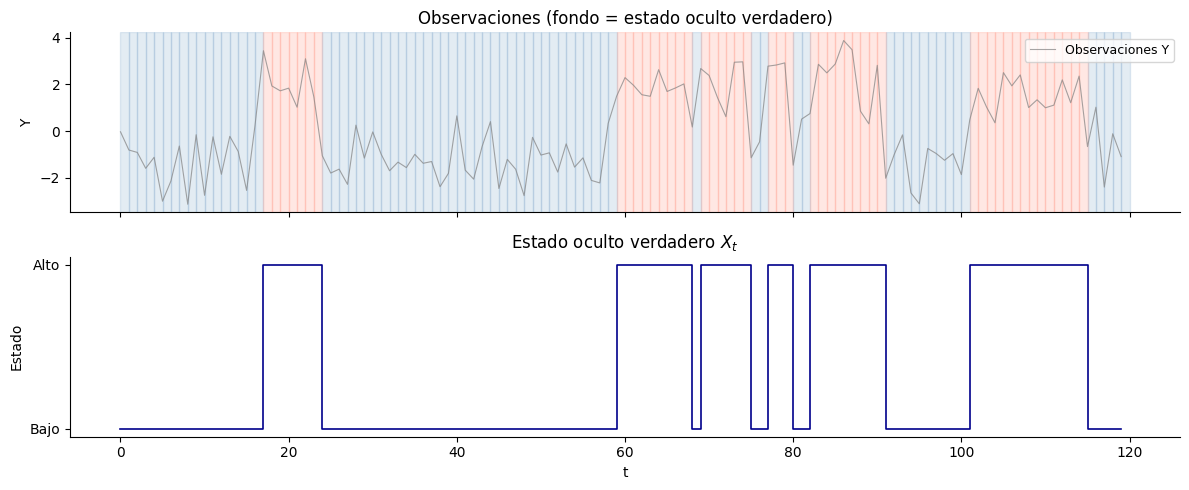

Fracción de tiempo en estado Alto: 0.400


In [2]:
# ─── Simular datos del HMM ───
T = 120   # longitud de la serie

# Simular estado oculto
X = np.zeros(T, dtype=int)
X[0] = 0   # empieza en estado Bajo
for t in range(1, T):
    X[t] = rng.choice(n_estados, p=K[X[t-1]])

# Simular observaciones
Y = np.array([rng.normal(mu_emision[X[t]], sig_emision[X[t]]) for t in range(T)])

# Visualizar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
colores = ['steelblue', 'tomato']

ax1.plot(Y, color='gray', linewidth=0.8, alpha=0.7, label='Observaciones Y')
for t in range(T):
    ax1.axvspan(t, t+1, alpha=0.15, color=colores[X[t]])
ax1.set_ylabel('Y'); ax1.set_title('Observaciones (fondo = estado oculto verdadero)')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2.step(range(T), X, color='darkblue', linewidth=1.2, where='post')
ax2.set_yticks([0, 1]); ax2.set_yticklabels(estados)
ax2.set_xlabel('t'); ax2.set_ylabel('Estado')
ax2.set_title('Estado oculto verdadero $X_t$')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()
print(f"Fracción de tiempo en estado Alto: {X.mean():.3f}")


In [3]:
# ─── Algoritmo hacia adelante (Forward Algorithm) ───
def forward_algorithm(Y, K, mu_emision, sig_emision, pi0=None):
    """
    Calcula las probabilidades filtradas phi_t(x) para todo t.
    
    Regresa
    -------
    phi : array (T, n_estados) — distribución filtrada en cada tiempo
    log_verosim : log-verosimilitud marginal de la secuencia Y
    """
    T = len(Y)
    n = K.shape[0]
    phi = np.zeros((T, n))
    log_verosim = 0.0

    # Distribución inicial (uniforme si no se especifica)
    if pi0 is None:
        pi0 = np.ones(n) / n

    # t = 0: filtrado inicial
    alpha = pi0 * np.array([norm.pdf(Y[0], mu_emision[i], sig_emision[i]) for i in range(n)])
    Z = alpha.sum()
    phi[0] = alpha / Z
    log_verosim += np.log(Z)

    # t = 1, ..., T-1
    for t in range(1, T):
        # Paso de predicción: propagar por kernel K
        pred = phi[t-1] @ K         # predictiva: φ_{t|t-1}

        # Paso de actualización: reponderar por verosimilitud (cambio de medida)
        lik = np.array([norm.pdf(Y[t], mu_emision[i], sig_emision[i]) for i in range(n)])
        alpha = pred * lik
        Z = alpha.sum()
        phi[t] = alpha / Z           # normalizar → distribución filtrada
        log_verosim += np.log(Z)

    return phi, log_verosim

phi, log_L = forward_algorithm(Y, K, mu_emision, sig_emision)

print(f"Log-verosimilitud marginal: {log_L:.3f}")
print(f"Muestra de phi_t (últimas 5 filas):")
print(phi[-5:].round(4))


Log-verosimilitud marginal: -196.344
Muestra de phi_t (últimas 5 filas):
[[8.520e-01 1.480e-01]
 [4.624e-01 5.376e-01]
 [9.998e-01 2.000e-04]
 [9.863e-01 1.370e-02]
 [9.992e-01 8.000e-04]]


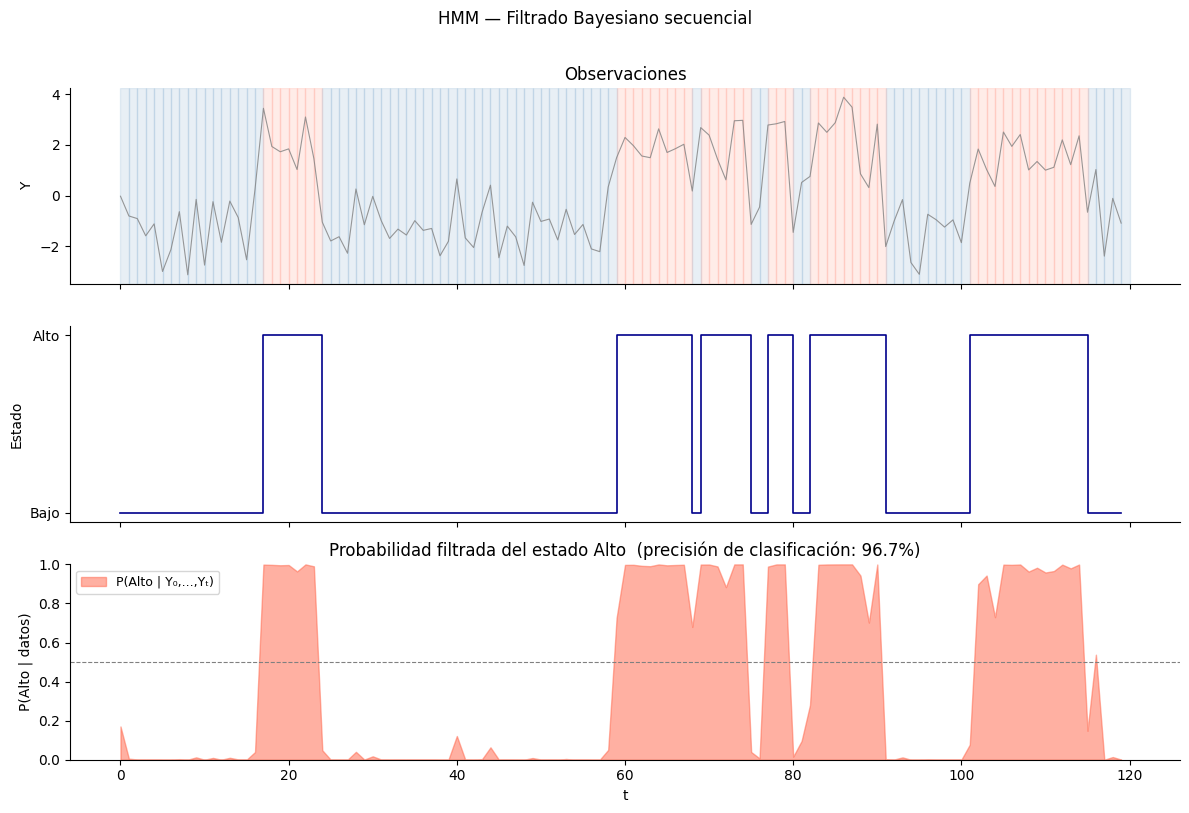

In [4]:
# ─── Visualizar filtrado ───
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Observaciones
axes[0].plot(Y, color='gray', lw=0.8, alpha=0.8)
for t in range(T):
    axes[0].axvspan(t, t+1, alpha=0.12, color=colores[X[t]])
axes[0].set_ylabel('Y'); axes[0].set_title('Observaciones')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Estado verdadero
axes[1].step(range(T), X, color='darkblue', lw=1.2, where='post', label='Estado verdadero')
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(estados)
axes[1].set_ylabel('Estado')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# Probabilidad filtrada del estado "Alto"
axes[2].fill_between(range(T), phi[:, 1], alpha=0.5, color='tomato', label='P(Alto | Y₀,...,Yₜ)')
axes[2].axhline(0.5, color='gray', linestyle='--', lw=0.8)
# Marcar aciertos
pred_estado = (phi[:, 1] > 0.5).astype(int)
acierto = (pred_estado == X).mean()
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('P(Alto | datos)')
axes[2].set_xlabel('t')
axes[2].set_title(f'Probabilidad filtrada del estado Alto  (precisión de clasificación: {acierto:.1%})')
axes[2].legend(fontsize=9)
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.suptitle('HMM — Filtrado Bayesiano secuencial', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 3. Conexión con cambio de medida

Como muestra Galindo (§11.4), cada paso del filtro es un **cambio de medida**:

$$\phi_t = \Psi_{g(y_t|\cdot)}(\phi_{t|t-1})$$

donde $\Psi_G(\eta)(dx) = \frac{G(x)}{\eta(G)}\eta(dx)$ es el operador de selección.

Esto es idéntico a la etapa de selección en algoritmos genéticos — con la verosimilitud jugando el papel del *fitness*.


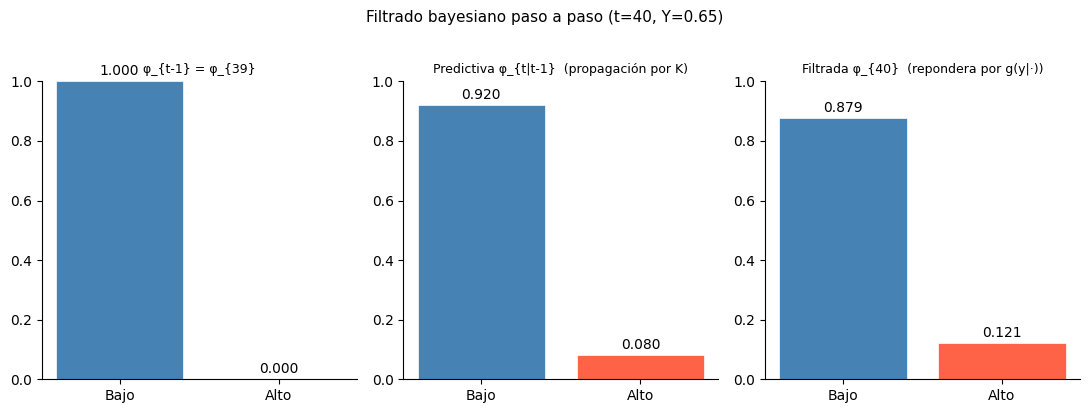

Estado verdadero en t=40: Bajo


In [5]:
# ─── Demostrar el cambio de medida paso a paso ───
t_ejemplo = 40
phi_prev = phi[t_ejemplo - 1]

# Predictiva (propagación por kernel K)
pred = phi_prev @ K

# Verosimilitud como potencial G
lik = np.array([norm.pdf(Y[t_ejemplo], mu_emision[i], sig_emision[i]) for i in range(n_estados)])

# Cambio de medida: phi_t = G * pred / (integral G * pred)
phi_actualizada = pred * lik / (pred * lik).sum()

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

for ax, vals, titulo in zip(axes,
    [phi_prev, pred, phi_actualizada],
    [f'φ_{{t-1}} = φ_{{{t_ejemplo-1}}}',
     f'Predictiva φ_{{t|t-1}}  (propagación por K)',
     f'Filtrada φ_{{{t_ejemplo}}}  (repondera por g(y|·))']):
    ax.bar(estados, vals, color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.5)
    ax.set_ylim(0, 1); ax.set_title(titulo, fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for j, v in enumerate(vals):
        ax.text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle(f'Filtrado bayesiano paso a paso (t={t_ejemplo}, Y={Y[t_ejemplo]:.2f})', fontsize=11, y=1.02)
plt.tight_layout(); plt.show()
print(f"Estado verdadero en t={t_ejemplo}: {estados[X[t_ejemplo]]}")


---
## Referencias
- Galindo, C. *Cambio de medida en probabilidad y análisis estocástico*, §11.4–§11.5.
- Rabiner, L. R. (1989). *A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition.*
